# Módulo 3 - Desafio 6
## Regresión Lineal

En este documento validaremos nuestros conocimientos sobre regresión lineal.
Para lograrlo, aplicaremos los modelos aprendidos en clase utilizando un dataset sobre peces 'fish.csv', el que contiene registros de ventas en el mercado de 7 especies comunes de peces diferentes.

Se busca realizar un modelo predictivo utilizando datos adecuados para máquinas, y así estimar el peso de los peces basándose en la longitud y ancho del pez.

In [1]:
import pandas as pd
from sklearn.metrics import median_absolute_error, mean_squared_error
import statsmodels.api as sm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Fish.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Weight,159.0,398.326415,357.978317,0.0000,120.00000,273.0000,650.0000,1650.000
Length1,159.0,26.247170,9.996441,7.5000,19.05000,25.2000,32.7000,59.000
Length2,159.0,28.415723,10.716328,8.4000,21.00000,27.3000,35.5000,63.400
Length3,159.0,31.227044,11.610246,8.8000,23.15000,29.4000,39.6500,68.000
Height,159.0,8.970994,4.286208,1.7284,5.94480,7.7860,12.3659,18.957
Width,159.0,4.417486,1.685804,1.0476,3.38565,4.2485,5.5845,8.142


In [3]:
df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [4]:
# Transformamos la columna 'Species' a categoria
df['Species'] = df['Species'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   Species  159 non-null    category
 1   Weight   159 non-null    float64 
 2   Length1  159 non-null    float64 
 3   Length2  159 non-null    float64 
 4   Length3  159 non-null    float64 
 5   Height   159 non-null    float64 
 6   Width    159 non-null    float64 
dtypes: category(1), float64(6)
memory usage: 8.1 KB


### Pregunta 1
Crea una nueva columna que incluya el volumen de pez, asumiéndolo como un cilindro. Para un cilindro con base circular, el área de la base ($A$) es igual a $\pi r^2$, donde $r$ es el radio de la base, y la altura ($h$) es la distancia entre las dos bases.
___
Con esto, calculamos $A \cdot h = \pi r^2 \cdot h$, donde la altura $h$ será el largo del pez. Dado que tenemos 3 largos, podemos calcular el promedio de los 3 largos definir $h$,

Definimos el volumen del pez con la siguiente formula:

$Volume = \pi \cdot height \cdot width^2$

In [5]:
# Agregamos la variable "volumen"
def add_volume_column(df):
    df['Volume'] = np.pi*df['Height']*(df['Width']/2)**2

add_volume_column(df)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   Species  159 non-null    category
 1   Weight   159 non-null    float64 
 2   Length1  159 non-null    float64 
 3   Length2  159 non-null    float64 
 4   Length3  159 non-null    float64 
 5   Height   159 non-null    float64 
 6   Width    159 non-null    float64 
 7   Volume   159 non-null    float64 
dtypes: category(1), float64(7)
memory usage: 9.3 KB


,Species,Weight,Length1,Length2,Length3,Height,Width,Volume
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,146.215854
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,181.707071
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,214.391723
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,198.477454
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,257.609344


### Pregunta 2
Verifica la correlación posible entre las variables, numérica y graficamente.
¿Aumenta la correlación entre el peso y longitues de los peces, altura y ancho al añadir el volumen? Explica



,Weight,Length1,Length2,Length3,Height,Width,Volume
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507,0.881981
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050,0.732409
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547,0.741313
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520,0.767774
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881,0.868256
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000,0.905626
Volume,0.881981,0.732409,0.741313,0.767774,0.868256,0.905626,1.000000


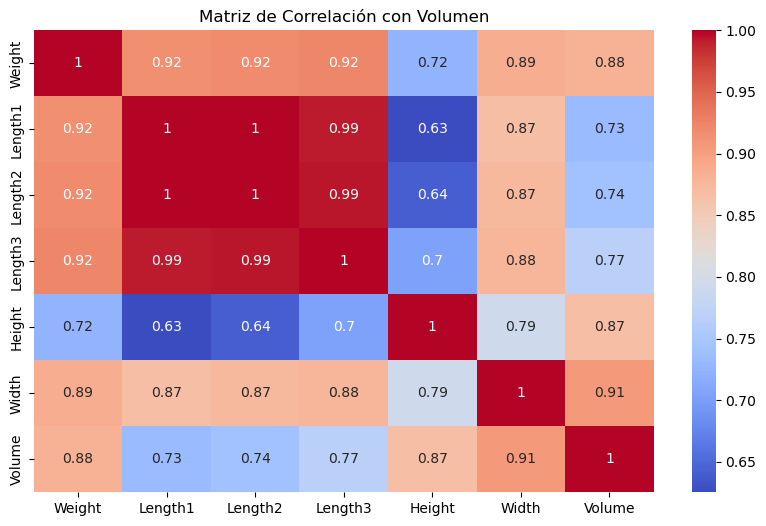

In [6]:
# Matriz de correlacion
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)
# heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación con Volumen')
plt.show()


Podemos ver que las variables numéricas más correlacionadas entre son los 3 largos (lengths), lo que tiene mucho sentido puesto que son distintas formas de medir el mismo atributo.

Además, estas 3 medidas de largo estan fuertemente correlacionadas con el peso. Esto podemos interpretarlo sencillamente como: a más grande un pez, mayor es su peso.

La altura se correlaciona en menor medida con el resto de variables, pero si fuertemente con el volumen.

El ancho también se correlaciona fuertemente con el peso y las otras medidas del pez (y en menor medida con la altura).

Por último, el volumen se correlaciona fuertemente con el peso, la altura y el ancho, y en menor medida con las medidas de largo.

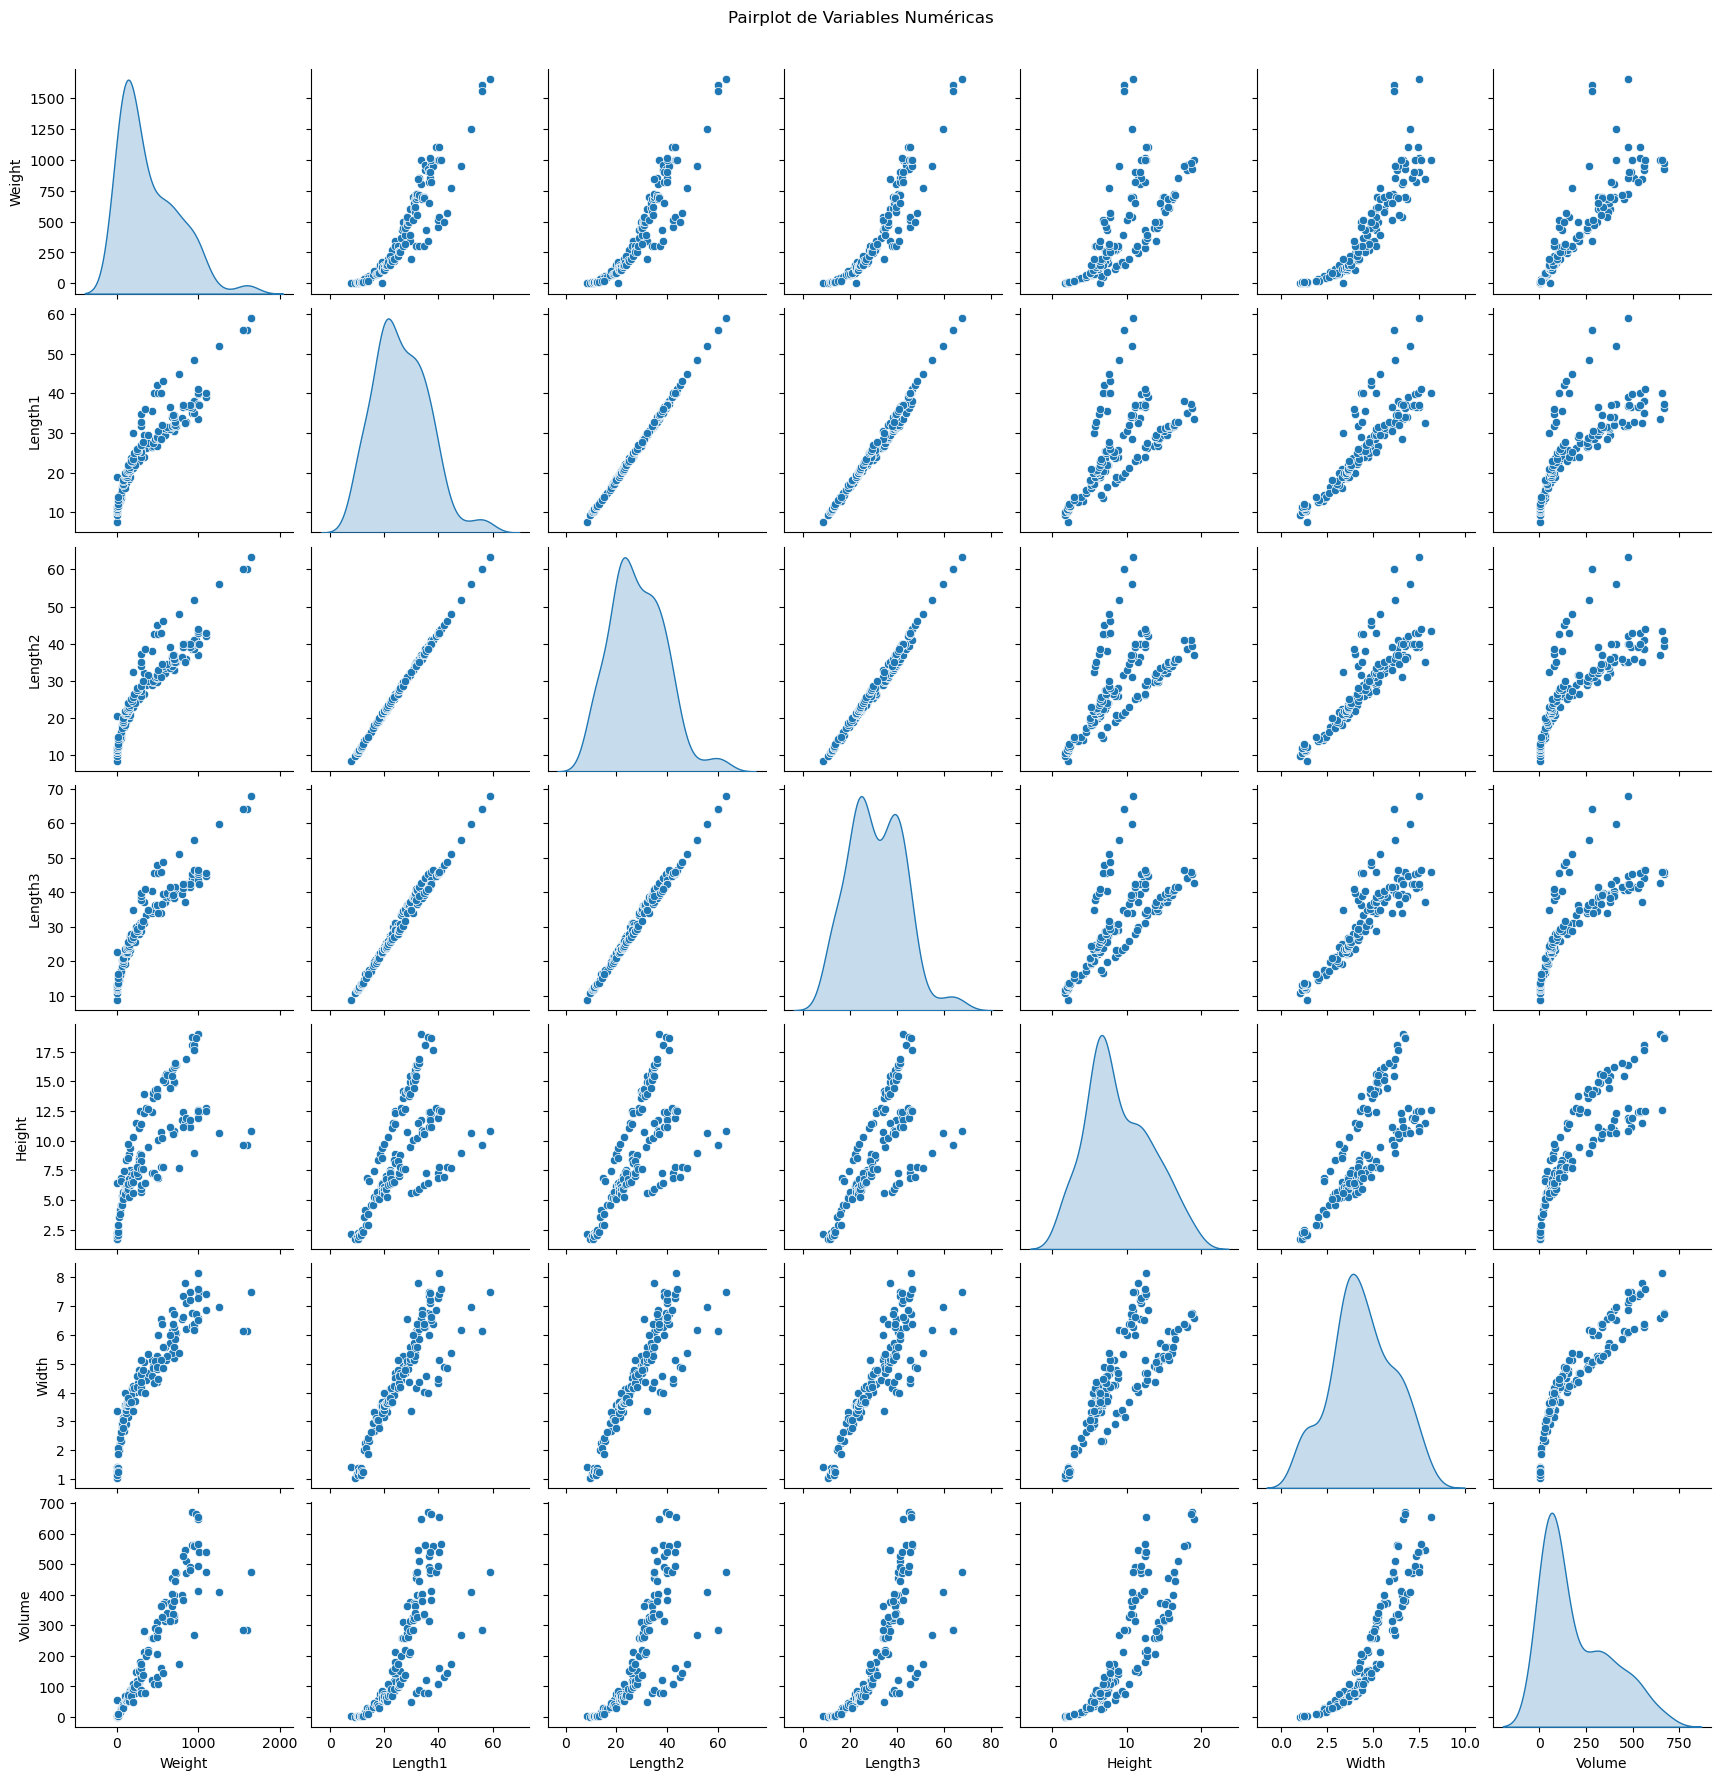

In [7]:
# Pairplot
sns.pairplot(df, diag_kind='kde')
plt.suptitle('Pairplot de Variables Numéricas', y=1.02)
plt.show()


Ahora, observando estas correlaciones gráficamente se nota lo siguiente:
- Los largos estan fuertemente relacionados entre sí, lo que se aprecia con la recta de sus gráficos.
- El volumen muestra una relación exponencial con respecto al resto de variables de longitud; el volumen crece rápidamente a medida que crece el largo, el ancho, o el alto.

Podemos decir que agregar la columna volumen a la muestra aumenta levemente la correlación entre el peso y la columna de altura en particular, que es la que más baja correlacion mostraba de todas las variables de longitud.

### Pregunta 3
Construye un modelo de regresión lineal que relacione el volumen y el peso de los peces. Realiza una breve evaluación del modelo y grafícalo.
___

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.776    
Dependent Variable: Weight           AIC:                2084.9801
Date:               2025-10-31 19:33 BIC:                2091.1180
No. Observations:   159              Log-Likelihood:     -1040.5  
Df Model:           1                F-statistic:        549.9    
Df Residuals:       157              Prob (F-statistic): 3.65e-53 
R-squared:          0.778            Scale:              28644.   
--------------------------------------------------------------------
            Coef.    Std.Err.      t      P>|t|     [0.025    0.975]
--------------------------------------------------------------------
const      58.7401    19.7453    2.9749   0.0034   19.7394   97.7407
Volume      1.7396     0.0742   23.4491   0.0000    1.5931    1.8861
------------------------------------------------------------------
Omnibus:              156.660      Durbin-Watson:         0.435   
Pro

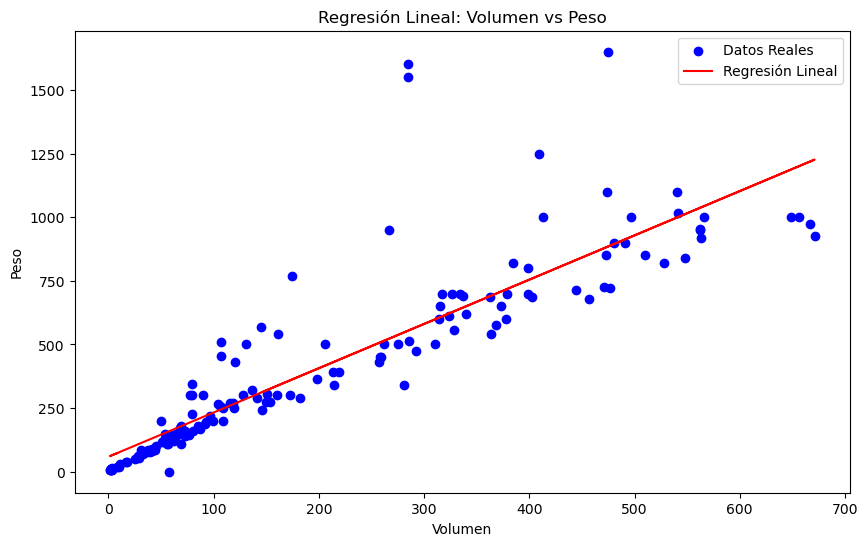

In [8]:
# Definimos las variables predictoras (X) y la variable de respuesta (y)
X = df['Volume']
y = df['Weight']

# Agregamos una constante a las variables predictoras para el intercepto
X = sm.add_constant(X)

# Construimos y entrenamos el modelo de regresión lineal
model = sm.OLS(y, X).fit()

# Resumen del modelo
print(model.summary2())

# Predicciones
y_pred = model.predict(X)

# Evaluación del modelo
mae = median_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
print("Error absoluto medio:", mae)
print("Error cuadrático medio:", mse)

# Grafico de la regresión
plt.figure(figsize=(10, 6))
plt.scatter(df['Volume'], df['Weight'], color='blue', label='Datos Reales')
plt.plot(df['Volume'], y_pred, color='red', label='Regresión Lineal')
plt.xlabel('Volumen')
plt.ylabel('Peso')
plt.title('Regresión Lineal: Volumen vs Peso')
plt.legend()
plt.show()


De los resultados numéricos podemos decir lo siguiente:
- El $R^2$ y el $R^2$ ajustado nos indican que el peso varía en un $77.8$% y $77.6$%, respectivamente, por el volumen. Esto nos dice que el volumen afecta en gran medida el peso del pez.
- El coeficiente del volumen nos dice qué tanto varía el peso por unidad de volumen, en este caso son $1.7396$ unidades de peso por unidad de volumen.
En general, el modelo se ajusta bien a los datos salvo los outliers que se encuentran a una distancia muy grande de la recta.

### Pregunta 4
¿Qué sucede si aplicas el modelo anterior por separado a cada especie de peces? Explica.
___
Primero revisaremos las especies unicas, y para cada tipo generaremos un modelo y revisaremos sus métricas.

In [9]:
# Revisar especies y su cantidad de registros
df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [10]:
# definimos una función para crear modelos por especie y otra para graficar
def plot_model(df, label, y_pred):
    plt.figure(figsize=(10, 6))
    plt.scatter(df['Volume'], df['Weight'], color='blue', label='Datos Reales')
    plt.plot(df['Volume'], y_pred, color='red', label='Regresión Lineal')
    plt.xlabel('Volumen')
    plt.ylabel('Peso')
    plt.title(f'Regresión Lineal: Volumen vs Peso para {label}')
    plt.legend()
    plt.show()

def model_by_species(df, tipo):
    data = df[df['Species'] == tipo]
    X = data['Volume']
    y = data['Weight']

    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    y_pred = model.predict(X)

    print(f"--- Especie: {tipo} ---")
    print(model.summary2())

    b1 = model.params['Volume']
    mae = median_absolute_error(y, y_pred)
    r_sqr = model.rsquared
    print("------------------------------------\n")
    return [y_pred, b1, mae, r_sqr, data.shape[0]]

--- Especie: Bream ---
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.895   
Dependent Variable: Weight           AIC:                396.5400
Date:               2025-10-31 19:33 BIC:                399.6507
No. Observations:   35               Log-Likelihood:     -196.27 
Df Model:           1                F-statistic:        289.7   
Df Residuals:       33               Prob (F-statistic): 6.65e-18
R-squared:          0.898            Scale:              4611.9  
------------------------------------------------------------------
             Coef.    Std.Err.     t     P>|t|    [0.025   0.975] 
------------------------------------------------------------------
const       108.1896   32.0693   3.3736  0.0019  42.9441  173.4351
Volume        1.3835    0.0813  17.0195  0.0000   1.2181    1.5489
-----------------------------------------------------------------
Omnibus:              0.744        Durbin-Watson:           1.871

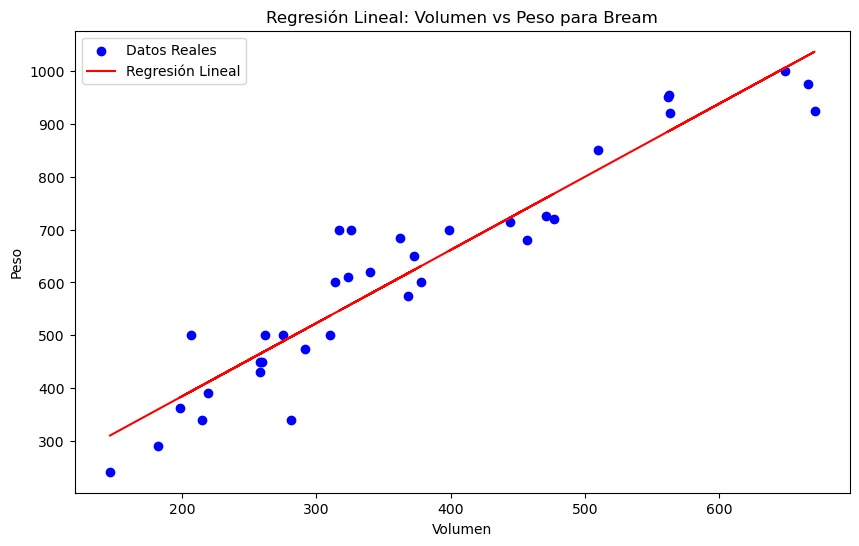

--- Especie: Parkki ---
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.995   
Dependent Variable: Weight           AIC:                70.8802 
Date:               2025-10-31 19:33 BIC:                71.6760 
No. Observations:   11               Log-Likelihood:     -33.440 
Df Model:           1                F-statistic:        1974.   
Df Residuals:       9                Prob (F-statistic): 7.41e-12
R-squared:          0.995            Scale:              31.275  
-------------------------------------------------------------------
            Coef.    Std.Err.      t      P>|t|    [0.025    0.975]
-------------------------------------------------------------------
const      12.1823     3.6261    3.3596   0.0084   3.9795   20.3852
Volume      1.7755     0.0400   44.4317   0.0000   1.6851    1.8659
-----------------------------------------------------------------
Omnibus:               0.671        Durbin-Watson:         

c:\Users\cabez\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)


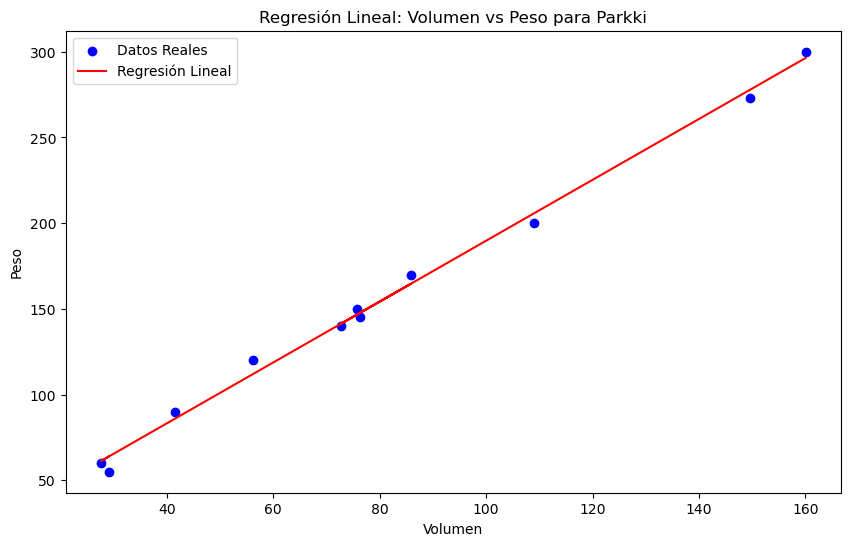

--- Especie: Perch ---
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.967   
Dependent Variable: Weight           AIC:                625.0432
Date:               2025-10-31 19:33 BIC:                629.0939
No. Observations:   56               Log-Likelihood:     -310.52 
Df Model:           1                F-statistic:        1617.   
Df Residuals:       54               Prob (F-statistic): 6.27e-42
R-squared:          0.968            Scale:              3978.1  
-------------------------------------------------------------------
           Coef.    Std.Err.      t      P>|t|     [0.025    0.975]
-------------------------------------------------------------------
const     34.9744    12.0677    2.8982   0.0054   10.7801   59.1686
Volume     1.7580     0.0437   40.2081   0.0000    1.6704    1.8457
-----------------------------------------------------------------
Omnibus:              11.982       Durbin-Watson:          1

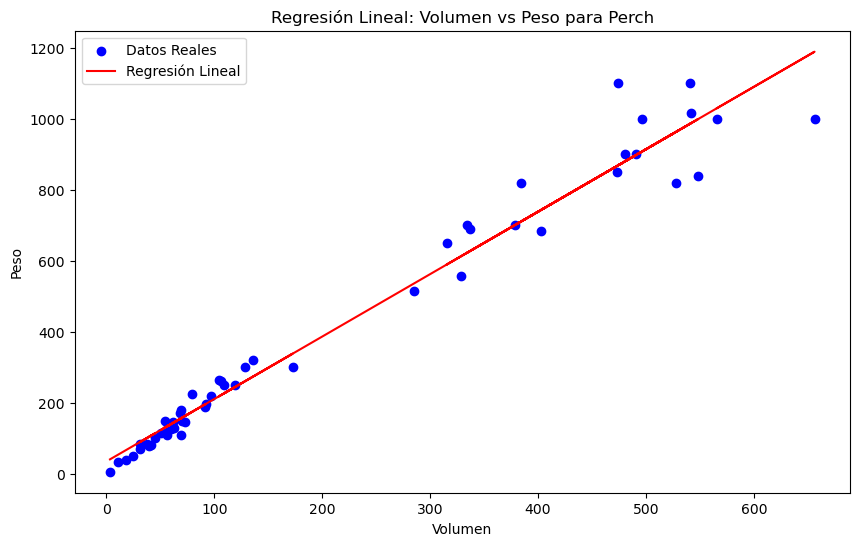

--- Especie: Pike ---
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.832   
Dependent Variable: Weight           AIC:                230.7003
Date:               2025-10-31 19:33 BIC:                232.3667
No. Observations:   17               Log-Likelihood:     -113.35 
Df Model:           1                F-statistic:        80.17   
Df Residuals:       15               Prob (F-statistic): 2.10e-07
R-squared:          0.842            Scale:              41052.  
------------------------------------------------------------------
             Coef.   Std.Err.    t     P>|t|     [0.025    0.975] 
------------------------------------------------------------------
const       60.6655   88.4097  0.6862  0.5031  -127.7753  249.1063
Volume       3.6777    0.4107  8.9536  0.0000     2.8022    4.5532
-----------------------------------------------------------------
Omnibus:               11.453       Durbin-Watson:          1.864


c:\Users\cabez\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


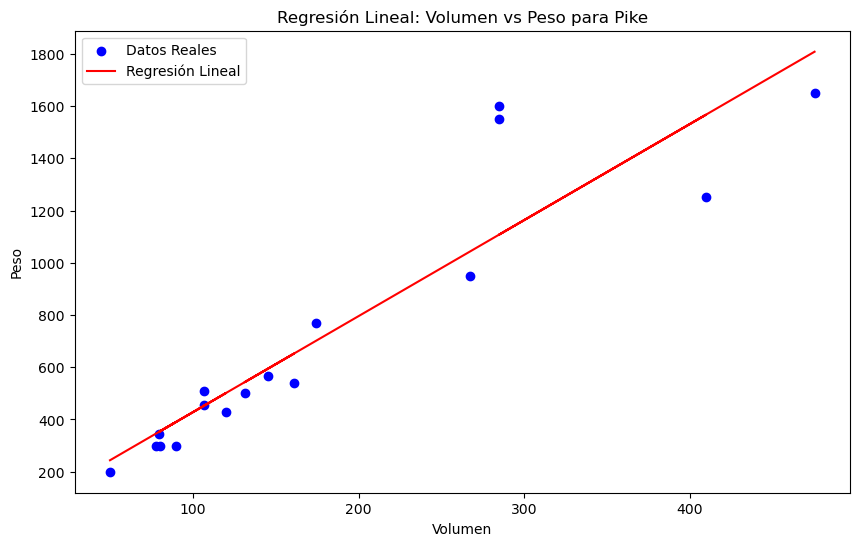

--- Especie: Roach ---
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.882   
Dependent Variable: Weight           AIC:                195.3261
Date:               2025-10-31 19:33 BIC:                197.3176
No. Observations:   20               Log-Likelihood:     -95.663 
Df Model:           1                F-statistic:        143.4   
Df Residuals:       18               Prob (F-statistic): 5.21e-10
R-squared:          0.888            Scale:              928.70  
-------------------------------------------------------------------
          Coef.    Std.Err.      t      P>|t|     [0.025     0.975]
-------------------------------------------------------------------
const    10.4907    13.6436    0.7689   0.4519   -18.1735   39.1548
Volume    1.8276     0.1526   11.9762   0.0000     1.5070    2.1482
-----------------------------------------------------------------
Omnibus:             38.157       Durbin-Watson:          1.

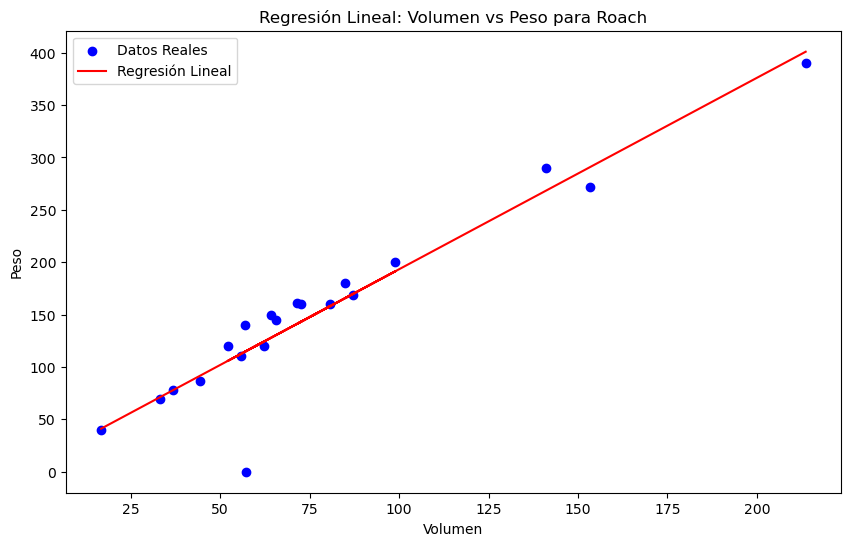

--- Especie: Smelt ---
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.868   
Dependent Variable: Weight           AIC:                52.9578 
Date:               2025-10-31 19:33 BIC:                54.2359 
No. Observations:   14               Log-Likelihood:     -24.479 
Df Model:           1                F-statistic:        86.39   
Df Residuals:       12               Prob (F-statistic): 7.84e-07
R-squared:          0.878            Scale:              2.2552  
--------------------------------------------------------------------
          Coef.     Std.Err.      t       P>|t|     [0.025    0.975]
--------------------------------------------------------------------
const     5.5697      0.7247    7.6852    0.0000    3.9906    7.1487
Volume    1.6270      0.1750    9.2949    0.0000    1.2456    2.0084
-----------------------------------------------------------------
Omnibus:              1.513        Durbin-Watson:      

c:\Users\cabez\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)


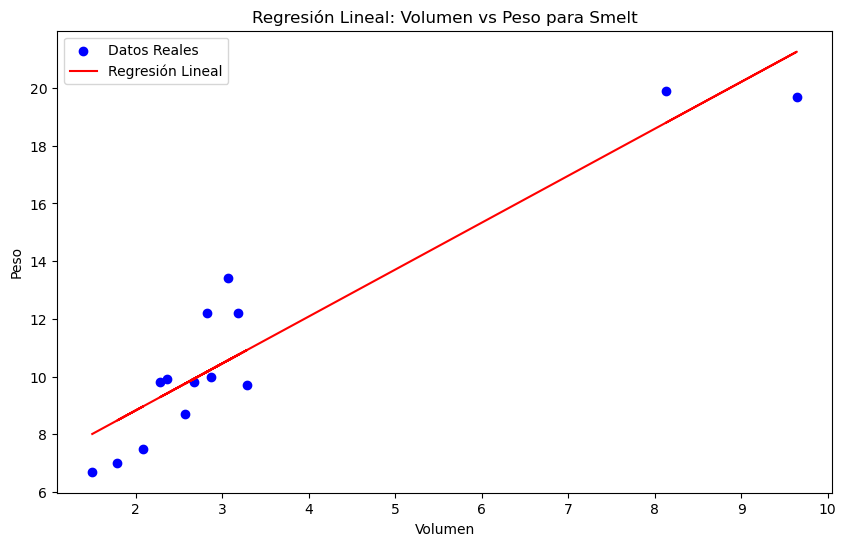

--- Especie: Whitefish ---
                Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.826  
Dependent Variable: Weight           AIC:                76.9411
Date:               2025-10-31 19:33 BIC:                76.5246
No. Observations:   6                Log-Likelihood:     -36.471
Df Model:           1                F-statistic:        24.66  
Df Residuals:       4                Prob (F-statistic): 0.00767
R-squared:          0.860            Scale:              16721. 
-----------------------------------------------------------------
            Coef.   Std.Err.    t     P>|t|     [0.025    0.975] 
-----------------------------------------------------------------
const      18.3115  115.9522  0.1579  0.8822  -303.6234  340.2464
Volume      1.9707    0.3968  4.9661  0.0077     0.8689    3.0725
----------------------------------------------------------------
Omnibus:              nan          Durbin-Watson:          1.507
Prob(Omnib

c:\Users\cabez\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


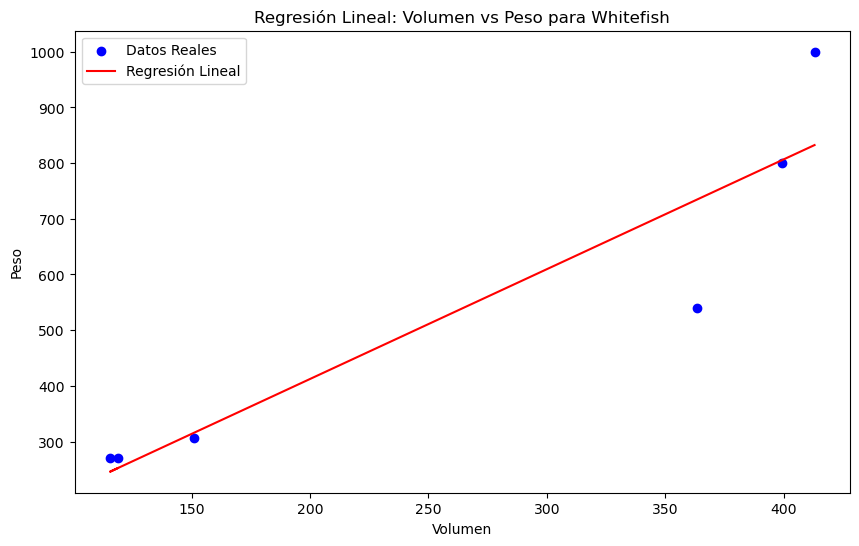

In [11]:
# Iteramos por especie
metricas = {}

for especie in df['Species'].cat.categories:
    [pred, b1, mae, r, count] = model_by_species(df, especie)
    df_species = df[df['Species'] == especie]
    plot_model(df_species, especie, pred)
    metricas[especie] = {'b1': b1, 'mae': mae, 'r^2': r, 'count': count}

In [12]:
display(pd.DataFrame(metricas).T)

,b1,mae,r^2,count
Bream,1.383521,41.562130,0.897726,35.0
Parkki,1.775532,4.035220,0.995462,11.0
Perch,1.758011,24.238221,0.967678,56.0
Pike,3.677672,68.209651,0.842382,17.0
Roach,1.827584,12.581573,0.888497,20.0
Smelt,1.627036,1.261013,0.878042,14.0
Whitefish,1.970687,20.897983,0.860443,6.0


En general vemos que la recta se ajusta bien a los datos, con algunas especies con puntos más lejanos a la recta (por ejemplo, la especie **Pyke** o **Whitefish**, ambos con pocos datos).

Por otro lado, si analizamos los estadísticos $\beta _1$ para cada especie, vemos justamente que el coeficiente de estas dos especies son los más altos, seguramente porque hay pocos datos y eso resulta en que un cambio en volumen afecte más al peso. Para el resto de especies, $\beta _1$ define bien en general la pendiente de la recta.

El estadístico mae también nos dice que los datos de la especie Pyke se alejan en promedio bastante de la predicción. Para la especie Bream, si bien los datos se encuentren en torno a la recta, son pocos los que estan directamente encima o muy cerca de esta. Por su parte, las especies **Parkki** y **Smelt** son las que, en promedio, tienen menor distancia a la recta. En el caso de Parkki es por que hay pocos datos.

Por último $r^2$ nos dice que tan fiable es cada modelo para predecir el peso por especie. En general, todos tienen valores sobre el 85%, siendo el mejor de estos el de la especie Parkki; pero, nuevamente hay que tener en cuenta que es de los que menos datos tiene. Seguiría entonces la especie Perch con un $96$% de confianza y del que mas se tienen datos. Por el contrario, Pyke y Whitefish son los que 'menos' confianza tienen y que también cuentan con pocos datos (en particular Whitefish), pero tampoco tienen un $r^2$ bajo; siguen siendo buenos modelos en general.

### Pregunta 5
Construye un modelo de regresión que relacione dos o más variables con el peso de los peces. Realiza una breve evaluación del modelo.
___
Utilizaremos las 3 medidas de largo y el ancho del pez, en base a las correlaciónes que vimos en la pregunta 2.

In [13]:
# Definimos las columnas predictoras (X) y la variable de respuesta (y)
X_multi = df[['Length3', 'Width', 'Height','Volume']]
Y = df['Weight']

# Agregamos una constante
X_multi = sm.add_constant(X_multi)

# Construimos y entrenamos el modelo de regresión lineal múltiple
model_multi = sm.OLS(Y, X_multi).fit()

# Resumen del modelo
print(model_multi.summary2())

# Predicciones
Y_pred_multi = model_multi.predict(X_multi)



                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.947    
Dependent Variable: Weight           AIC:                1860.3755
Date:               2025-10-31 19:33 BIC:                1875.7201
No. Observations:   159              Log-Likelihood:     -925.19  
Df Model:           4                F-statistic:        700.7    
Df Residuals:       154              Prob (F-statistic): 1.13e-97 
R-squared:          0.948            Scale:              6847.6   
-------------------------------------------------------------------
           Coef.    Std.Err.     t     P>|t|     [0.025     0.975] 
-------------------------------------------------------------------
const    -171.1651   30.9809  -5.5249  0.0000  -232.3676  -109.9627
Length3    22.6747    1.2083  18.7655  0.0000    20.2877    25.0618
Width     -53.3528   12.4947  -4.2700  0.0000   -78.0358   -28.6697
Height    -22.6814    3.1232  -7.2623  0.0000   -28.8513   -16.5116
Volume

Vemos que el modelo es confiable ($r^2$ cercano al $95$%), pero también vemos números extraños en los coeficientes. 

Esto puede deberse a que, en realidad, todas estas medidas de longitud dependen unas de otras en distinta medida para cada especie.

Además, ocurre un problema con los coeficientes de altura y ancho, el que se debe a que el volumen esta calculado a partir de estas. Esto provoca que sus coeficientes sean negativos, es decir, que a mayor ancho y altura $=>$ menor peso, lo que no tiene mucho sentido. 

Por último, el estadístico F $=700.7$ y el valor p cercano a $0$ nos dice que el modelo, en general, es altamente significativo.

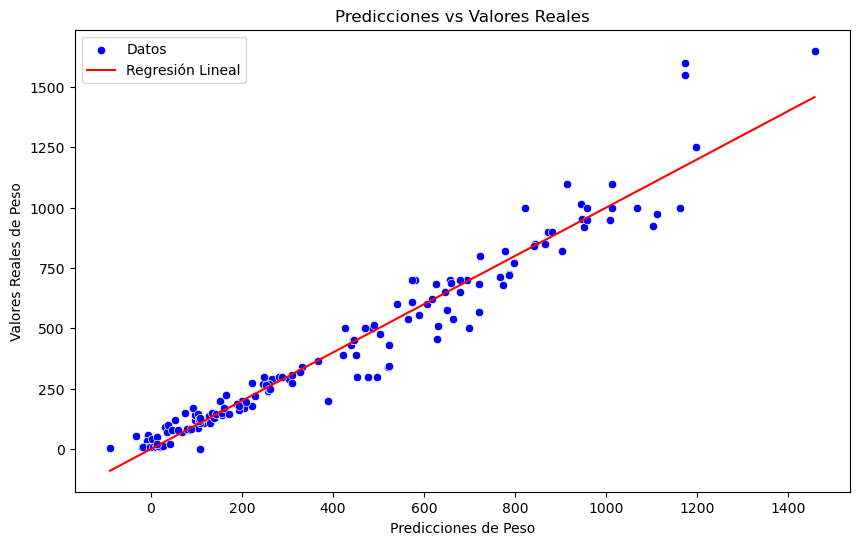

In [14]:
# Gráfico de Predicciones vs Valores Reales
plt.figure(figsize=(10, 6))
sns.scatterplot(x=Y_pred_multi, y=Y, color='blue', label='Datos')
plt.plot(   [Y_pred_multi.min(), Y_pred_multi.max()],\
            [Y_pred_multi.min(), Y_pred_multi.max()],\
            color='red', label='Regresión Lineal')
plt.xlabel('Predicciones de Peso')
plt.ylabel('Valores Reales de Peso')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.show()

In [15]:
# Evaluación del modelo
mae_multi = median_absolute_error(Y, Y_pred_multi)
mse_multi = mean_squared_error(Y, Y_pred_multi)
r = model_multi.rsquared

print("\nError absoluto medio (múltiple):", mae_multi)
print("Error cuadrático medio (múltiple):", mse_multi)
print("R cuadrado (múltiple):", r)


Error absoluto medio (múltiple): 26.001042797703445
Error cuadrático medio (múltiple): 6632.2871276390715
R cuadrado (múltiple): 0.9479177288519025


El gráfico nos refuerza el análisis mostrando que la recta se ajusta bastante bien a los datos.